In [5]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def load_token_arrays(token, h5_path="stats.h5"):
    """
    Load all metric arrays for a given token.
    Returns a dict mapping each metric to an array of shape (N, L, H).
    token ∈ {"rel", "A", "B"}.
    """
    assert token in {"rel", "A", "B"}, "Wrong token key!"
    stats = []

    with h5py.File(h5_path, "r") as f:
        scenes = f["scenes"]

        # ---------------------------------------
        # Find metrics for this token from first scene that contains it
        # ---------------------------------------
        metric_names = None
        for scene_id in scenes.keys():
            scene = scenes[scene_id]
            if token in scene:
                metric_names = list(scene[token].keys())
                break
        if metric_names is None:
            raise KeyError(f"Token '{token}' not found in any scene.")

        # Prepare collectors
        collectors = {metric: [] for metric in metric_names}

        # ---------------------------------------
        # Gather (L, H) matrices for each scene
        # ---------------------------------------
        for scene_id in scenes.keys():
            scene = scenes[scene_id]
            if token not in scene:
                continue

            grp = scene[token]
            for metric in metric_names:
                arr = grp[metric][()]     # shape (L, H)
                collectors[metric].append(arr)

        # ---------------------------------------
        # Stack statistics
        # ---------------------------------------
        stacked_stats = {}
        for metric, mats in collectors.items():
            if len(mats) == 0:
                continue

            stack = np.stack(mats, axis=0)  # shape: (num_scenes, L, H)
            stacked_stats[metric] = stack
            
    return stacked_stats

In [7]:
def df_from_metric_dict(metric_dict):
    """
    metric_dict: {
        "<metric_name>": array_of_shape_(N, L, H),
        ...
    }

    Returns a tidy DataFrame:
        scene, layer, head, head_id, metric1, metric2, ...
    """
    # Validate shapes
    shapes = [arr.shape for arr in metric_dict.values()]
    assert all(s == shapes[0] for s in shapes), \
    f"All metric arrays must share the same shape, got: {shapes}"

    N, L, H = shapes[0]

    # ----------------------------------------------------------------------
    # Build universal indices (scene, layer, head, head_id)
    # ----------------------------------------------------------------------
    scenes = np.repeat(np.arange(N), L * H)
    layers = np.tile(np.repeat(np.arange(L), H), N)
    heads  = np.tile(np.arange(H), N * L)
    head_ids = layers * H + heads   # globally unique 0..L*H-1

    # ----------------------------------------------------------------------
    # Build DataFrame
    # ----------------------------------------------------------------------
    df = pd.DataFrame({
        "scene": scenes,
        "layer": layers,
        "head": heads,
        "head_id": head_ids,
    })

    # Add each metric as a column
    for metric_name, arr in metric_dict.items():
        df[metric_name] = arr.reshape(-1)

    return df

In [8]:
rel_metric_dict = load_token_arrays("rel")
print(rel_metric_dict.keys())

dict_keys(['com_relation', 'com_union', 'entropy', 'iou_relation', 'iou_union'])


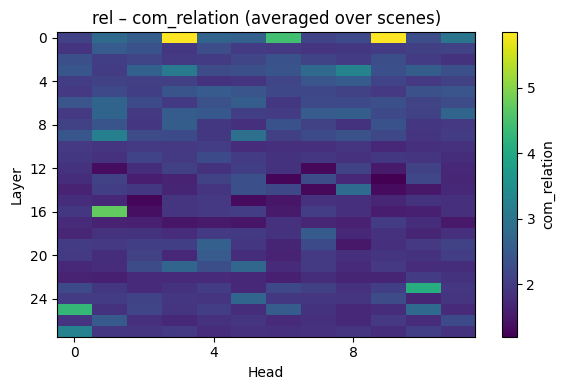

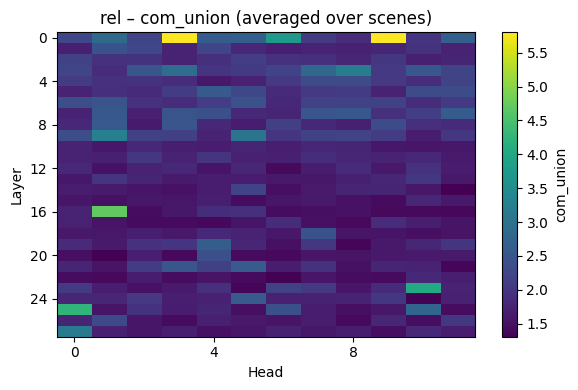

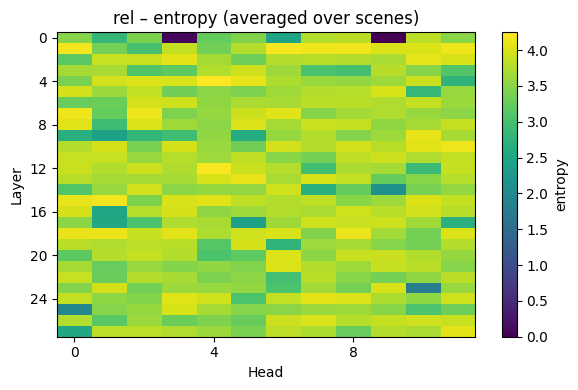

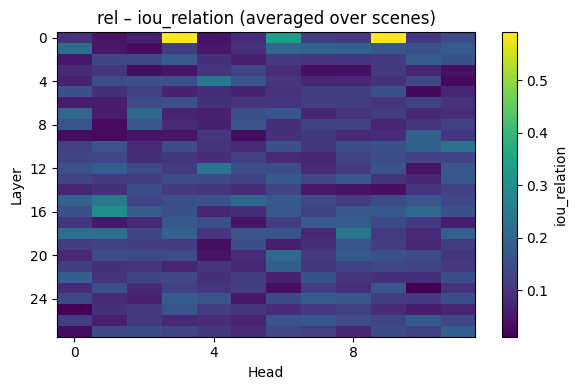

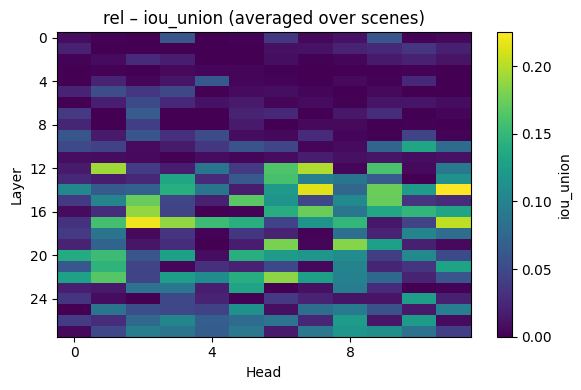

In [9]:
# Plot one heatmap per metric
for metric, arr in rel_metric_dict.items():
    arr = arr.mean(axis=0) # Average over scenes (L, H)
    L, H = arr.shape

    plt.figure(figsize=(6, 4))
    plt.imshow(arr, aspect="auto")   # arr is (L, H)
    plt.colorbar(label=metric)
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.title(f"rel – {metric} (averaged over scenes)")

    plt.xticks(np.arange(0, H, step=4))
    plt.yticks(np.arange(L, step=4))
    plt.tight_layout()
    plt.show()

In [10]:
rel_df = df_from_metric_dict(rel_metric_dict)
rel_df.head()

,scene,layer,head,head_id,com_relation,com_union,entropy,iou_relation,iou_union
0,0,0,0,0,3.884980,2.105033,3.393327,0.024390,0.000000
1,0,0,1,1,4.428272,2.806573,3.040217,0.023810,0.000000
2,0,0,2,2,3.843743,2.229966,3.775753,0.045455,0.000000
3,0,0,3,3,7.632160,7.071057,0.060509,0.444444,0.098765
4,0,0,4,4,3.561824,1.782346,3.594521,0.024390,0.000000


In [11]:
def plot_layer_trends(df, left_metric, right_metric=None):
    """
    Plot layer-wise mean ± std trends for one or two metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain 'layer' and the requested metric columns.
    left_metric : str
        Metric plotted on the left y-axis.
    right_metric : str or None, optional
        Metric plotted on the right y-axis. If None, only left_metric is shown.
    """

    # --- Aggregate ---
    agg_dict = {left_metric: ["mean", "std"]}
    if right_metric is not None:
        agg_dict[right_metric] = ["mean", "std"]

    layer_stats = df.groupby("layer").agg(agg_dict)
    layers = layer_stats.index

    # --- Left metric ---
    left_mean = layer_stats[left_metric]["mean"]
    left_std  = layer_stats[left_metric]["std"]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    color_left = "tab:blue"

    ax1.set_xlabel("Layer Index", fontsize=12)
    ax1.set_ylabel(f"{left_metric}", color=color_left, fontsize=12)
    ax1.plot(layers, left_mean, color=color_left, marker="o", label=f"{left_metric} mean")
    ax1.fill_between(layers, left_mean - left_std, left_mean + left_std,
                     color=color_left, alpha=0.2)
    ax1.tick_params(axis="y", labelcolor=color_left)
    ax1.grid(True, alpha=0.3)

    # --- Optional right metric ---
    if right_metric is not None:
        right_mean = layer_stats[right_metric]["mean"]
        right_std  = layer_stats[right_metric]["std"]

        ax2 = ax1.twinx()
        color_right = "tab:orange"

        ax2.set_ylabel(f"{right_metric}", color=color_right, fontsize=12)
        ax2.plot(layers, right_mean, color=color_right, linestyle="--", marker="s",
                 label=f"{right_metric} mean")
        ax2.fill_between(layers, right_mean - right_std, right_mean + right_std,
                         color=color_right, alpha=0.2)
        ax2.tick_params(axis="y", labelcolor=color_right)

        # Combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2,
                   loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

    plt.title("Layer-wise Metric Trends", fontsize=14)
    fig.tight_layout()
    plt.show()

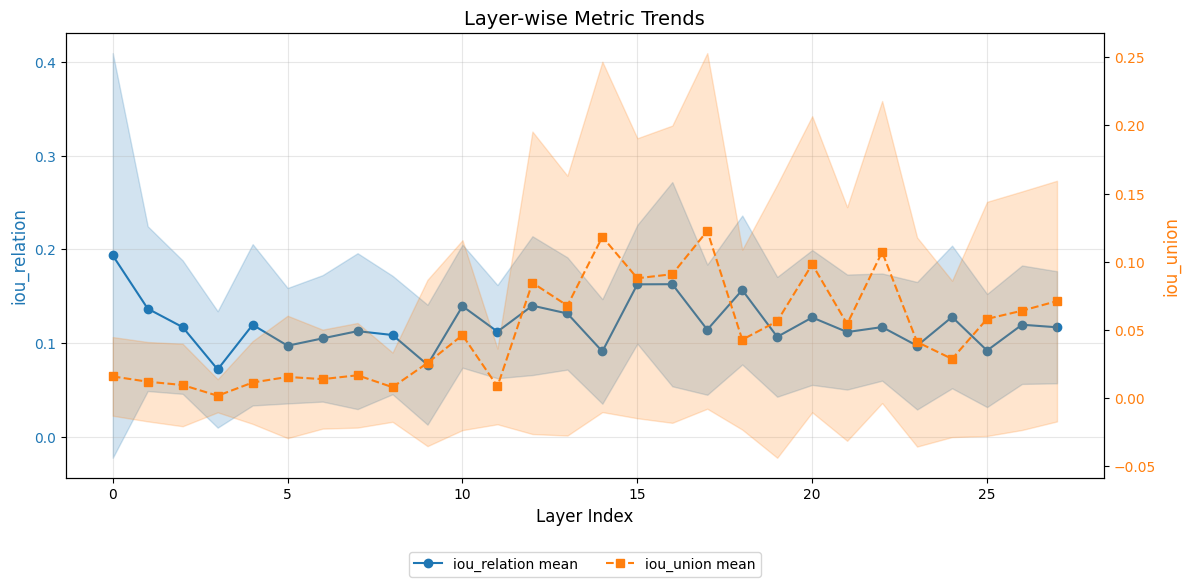

In [12]:
plot_layer_trends(rel_df, "iou_relation", "iou_union")

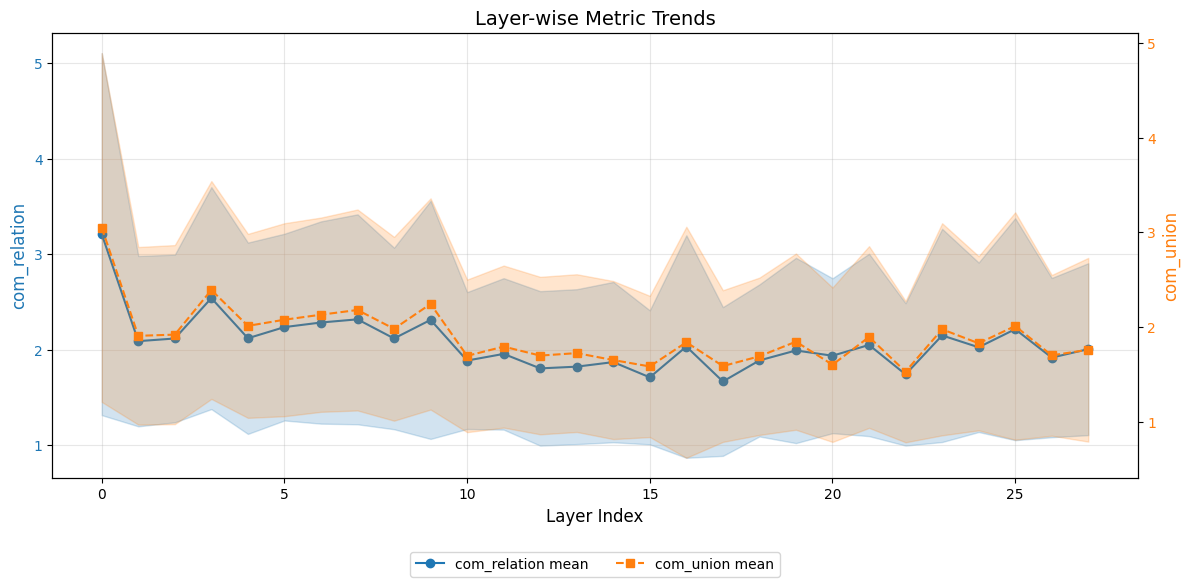

In [13]:
plot_layer_trends(rel_df, "com_relation", "com_union")

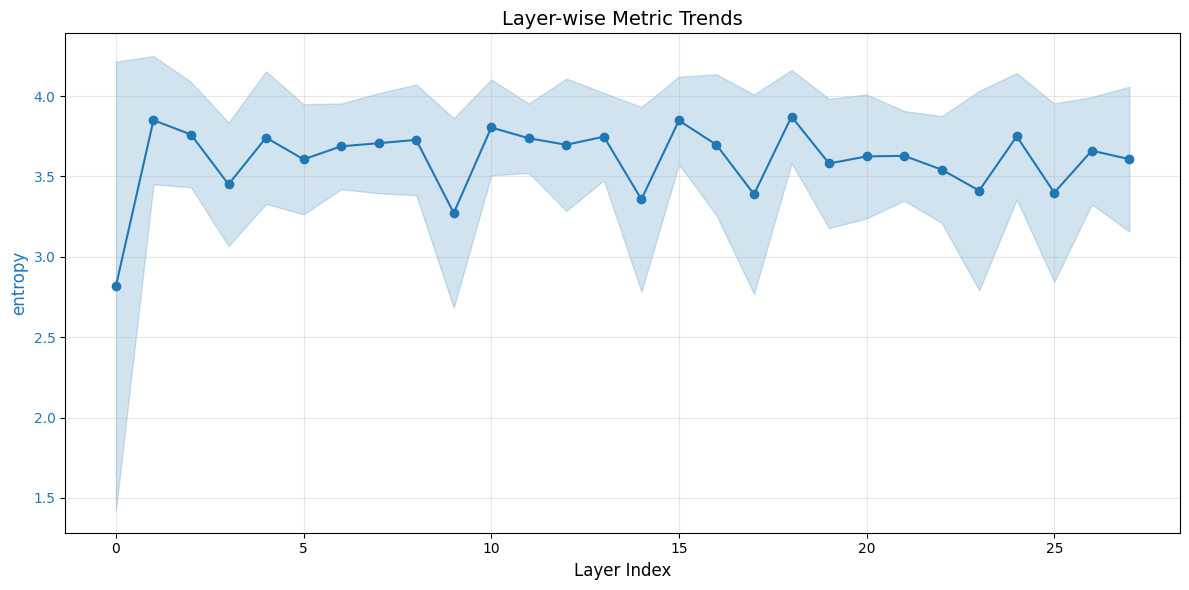

In [14]:
plot_layer_trends(rel_df, "entropy")

In [15]:
def load_baseline_arrays(baseline_name, h5_path="stats.h5"):
    """
    Load all baseline metric arrays for a given baseline ("uniform" or "gaussian").

    Returns:
        dict {metric_name: array of shape (N, L, H)}
    """
    assert baseline_name in {"uniform", "gaussian"}, "Wrong baseline key!"
    with h5py.File(h5_path, "r") as f:
        scenes = f["scenes"]

        # Find metric names from first scene
        metric_names = None
        for scene_id in scenes:
            scene = scenes[scene_id]
            if "baselines" in scene and baseline_name in scene["baselines"]:
                metric_names = list(scene["baselines"][baseline_name].keys())
                break
        if metric_names is None:
            raise KeyError(f"No baseline '{baseline_name}' found in any scene.")

        collectors = {metric: [] for metric in metric_names}

        # Collect arrays
        for scene_id in scenes:
            scene = scenes[scene_id]
            if "baselines" not in scene or baseline_name not in scene["baselines"]:
                continue

            grp = scene["baselines"][baseline_name]
            for metric in metric_names:
                arr = grp[metric][()]  # (L, H)
                collectors[metric].append(arr)

    # Stack into (N, L, H)
    for metric in collectors:
        collectors[metric] = np.stack(collectors[metric], axis=0)

    return collectors

In [16]:
uniform_metric_dict = load_baseline_arrays("uniform")
gaussian_metric_dict = load_baseline_arrays("gaussian")

In [17]:
df_unif = df_from_metric_dict(uniform_metric_dict)
df_gauss = df_from_metric_dict(gaussian_metric_dict)

In [18]:
rel_df["kind"]   = "real"
df_unif["kind"] = "uniform"
df_gauss["kind"]   = "gaussian"

df_all = pd.concat([rel_df, df_unif, df_gauss], ignore_index=True)

In [19]:
metrics = ["iou_relation", "iou_union", "com_relation", "com_union", "entropy"]
grouped_df = df_all.groupby(["kind", "layer", "head"])[metrics].mean()

In [20]:
grouped_df.loc[("real", 0)]

,iou_relation,iou_union,com_relation,com_union,entropy
head,,,,,
0,0.094132,0.007059,2.092388,2.262980,3.472180e+00
1,0.042569,0.002028,2.794107,2.868440,2.830841e+00
2,0.065362,0.000764,2.569015,2.251637,3.412199e+00
3,0.590800,0.059726,5.842629,5.799540,6.795286e-02
4,0.044583,0.000017,2.674607,2.615529,3.236298e+00
5,0.084999,0.001786,2.618667,2.669807,3.440847e+00
6,0.334151,0.036399,4.439323,3.730006,2.477322e+00
7,0.111919,0.004941,2.146270,2.075489,3.765761e+00
8,0.110249,0.010704,2.226480,1.885381,3.802646e+00


<Axes: xlabel='layer', ylabel='com_relation'>

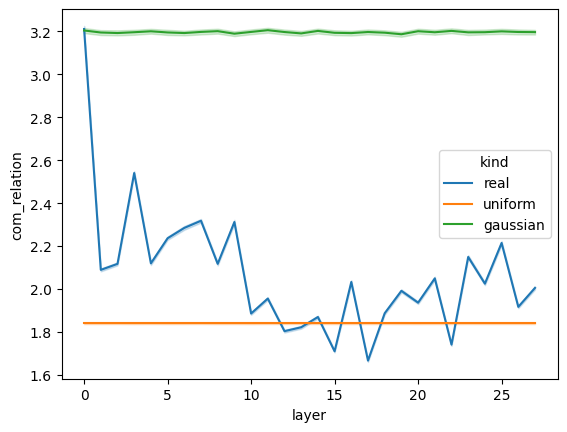

In [21]:
sns.lineplot(data=df_all, x="layer", y="com_relation", hue="kind")

<Axes: xlabel='layer', ylabel='com_union'>

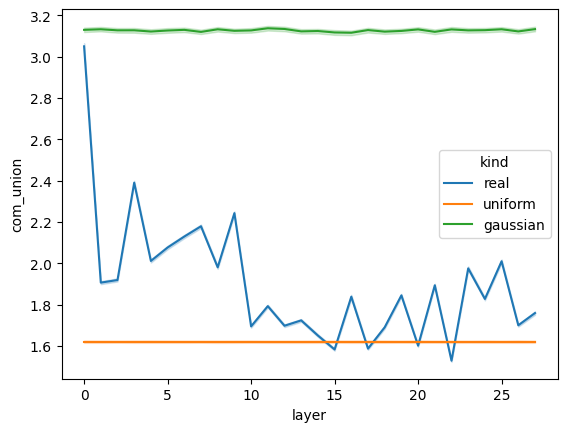

In [22]:
sns.lineplot(data=df_all, x="layer", y="com_union", hue="kind")

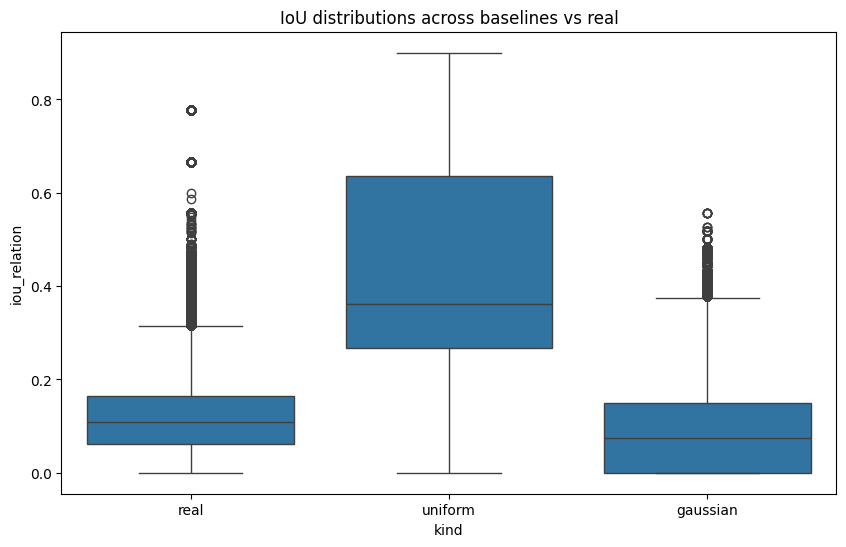

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x="kind", y="iou_relation")
plt.title("IoU distributions across baselines vs real")
plt.show()

# Analysis: Metrics vs. Number of Shapes

Analyze how attention quality metrics (IoU, Entropy, Center of Mass) vary with scene complexity (number of shapes in the scene).

In [46]:
# Load scene annotations to get number of shapes
import jsonlines

def load_scene_annotations(annotation_file="synthetic_dataset/annotations.jsonl"):
    """Load scene metadata including number of shapes."""
    annotations = {}
    with jsonlines.open(annotation_file) as reader:
        for record in reader:
            scene_id = record["scene_id"]
            # Total shapes = 2 (main objects A and B) + num_distractors
            total_shapes = 2 + record["num_distractors"]
            annotations[scene_id] = {
                "num_distractors": record["num_distractors"],
                "num_shapes": total_shapes,
                "relation": record["relation_AB"]
            }
    return annotations

annotations = load_scene_annotations()
print(f"Loaded {len(annotations)} scene annotations")
print(f"Shape count range: {min(a['num_shapes'] for a in annotations.values())} - {max(a['num_shapes'] for a in annotations.values())}")

Loaded 5000 scene annotations
Shape count range: 3 - 9


In [47]:
# Add shape count information to our dataframe
# Map scene index to scene_id
scene_id_map = {i: f"scene_{i:04d}" for i in range(len(annotations))}

# Add num_shapes column to rel_df
rel_df["scene_id"] = rel_df["scene"].map(scene_id_map)
rel_df["num_shapes"] = rel_df["scene_id"].map(lambda x: annotations[x]["num_shapes"] if x in annotations else None)
rel_df["num_distractors"] = rel_df["scene_id"].map(lambda x: annotations[x]["num_distractors"] if x in annotations else None)

# Remove any rows without annotation data
rel_df_clean = rel_df.dropna(subset=["num_shapes"])

print(f"Total data points: {len(rel_df_clean)}")
print(f"Scenes: {rel_df_clean['scene_id'].nunique()}")
print(f"Shape counts found: {sorted(rel_df_clean['num_shapes'].unique())}")
print(f"\nSample data:")
rel_df_clean[["scene_id", "layer", "head", "num_shapes", "iou_relation", "entropy"]].head()

Total data points: 1680000
Scenes: 5000
Shape counts found: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Sample data:


,scene_id,layer,head,num_shapes,iou_relation,entropy
0,scene_0000,0,0,4,0.024390,3.393327
1,scene_0000,0,1,4,0.023810,3.040217
2,scene_0000,0,2,4,0.045455,3.775753
3,scene_0000,0,3,4,0.444444,0.060509
4,scene_0000,0,4,4,0.024390,3.594521


## Layer-wise IoU Trends by Scene Complexity

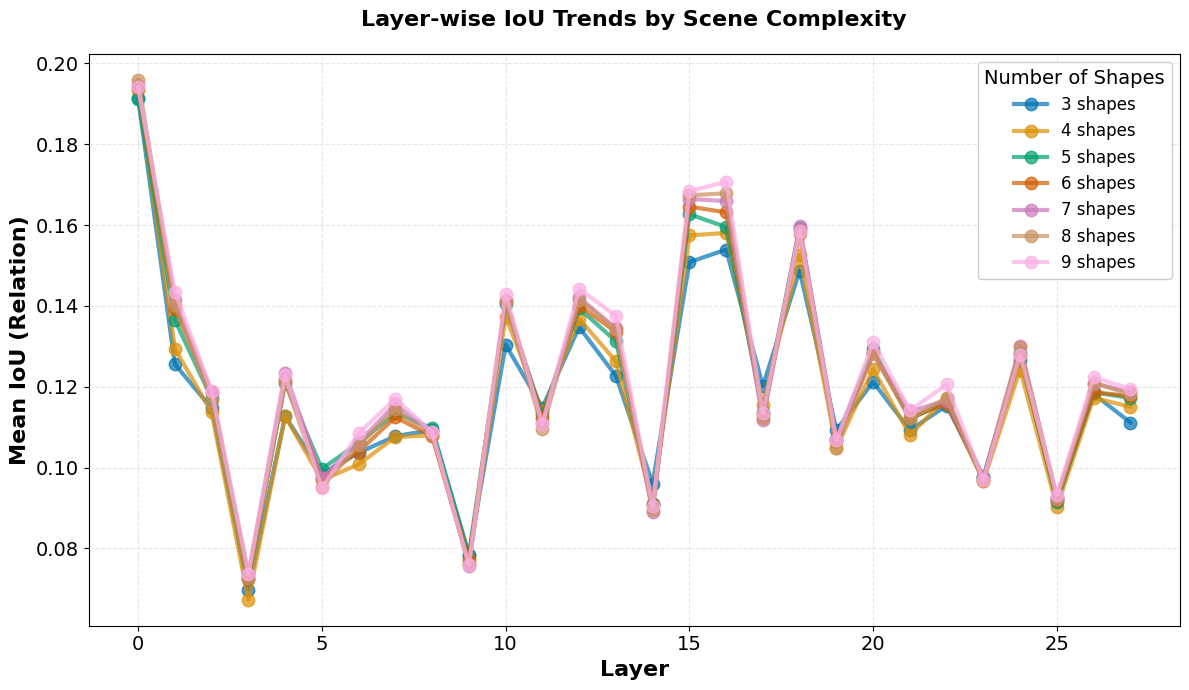

In [48]:
# Create isolated plot: Layer-wise IoU trends by complexity
fig, ax = plt.subplots(figsize=(12, 7))

# Aggregate across layers and shape counts
layer_shape_agg = rel_df_clean.groupby(["layer", "num_shapes"])["iou_relation"].mean().reset_index()

colors = sns.color_palette("colorblind", n_colors=7)

# Line plot: one line per shape count with better styling
for i, shape_count in enumerate(shape_counts):
    subset = layer_shape_agg[layer_shape_agg["num_shapes"] == shape_count]
    ax.plot(subset["layer"], subset["iou_relation"],
            marker='o', linewidth=3, markersize=9, 
            label=f"{int(shape_count)} shapes",
            color=colors[i], alpha=0.7)

ax.set_xlabel("Layer", fontsize=16, fontweight="bold")
ax.set_ylabel("Mean IoU (Relation)", fontsize=16, fontweight="bold")
ax.set_title("Layer-wise IoU Trends by Scene Complexity", fontsize=16, fontweight="bold", pad=20)
ax.legend(title="Number of Shapes", fontsize=12, title_fontsize=14, loc="best", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle="--")
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.show()